In [6]:
  # ============================================================
  # CELL 1: MOUNT DRIVE & INSTALL
  # ============================================================
  import os, time
  from google.colab import drive

  drive.mount('/content/drive')

  os.system("pip install -q ultralytics opencv-python scikit-learn matplotlib seaborn")

  import numpy as np
  import cv2
  import tensorflow as tf
  from tensorflow import keras
  from tensorflow.keras import layers
  from sklearn.model_selection import train_test_split
  from sklearn.metrics import classification_report, confusion_matrix
  import matplotlib.pyplot as plt
  import seaborn as sns
  import warnings
  warnings.filterwarnings('ignore')

  print(f"TensorFlow: {tf.__version__}")
  print(f"GPU: {tf.config.list_physical_devices('GPU')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
  # ============================================================
  # CELL 2: PATHS & HYPERPARAMETERS
  # ============================================================

  import os

  BASE_PATH = '/content/drive/My Drive/CarCrashDetection'
  DATA_DIR = BASE_PATH + '/data'
  DATASET_DIR = DATA_DIR + '/dataset'
  FEATURES_DIR = DATA_DIR + '/features_v2'
  MODELS_DIR = BASE_PATH + '/models'
  RESULTS_DIR = BASE_PATH + '/results'
  CRASH_VIDEOS_DIR = '/tmp/crash_extracted'
  NORMAL_VIDEOS_DIR = '/tmp/normal_extracted'

  for d in [DATA_DIR, DATASET_DIR, FEATURES_DIR, MODELS_DIR, RESULTS_DIR]:
      os.makedirs(d, exist_ok=True)

  FRAMES_PER_VIDEO = 10
  FRAME_SIZE = 112
  FEATURE_DIM = 1280
  BATCH_SIZE = 32
  EPOCHS = 50
  LR = 1e-3
  TEST_SIZE = 0.2
  RANDOM_SEED = 42

  print("Config ready")

Config ready


In [8]:
  # ============================================================
  # CELL 3: EXTRACT VIDEOS FROM ZIP
  # ============================================================
  import zipfile, shutil

  os.makedirs(CRASH_VIDEOS_DIR,  exist_ok=True)
  os.makedirs(NORMAL_VIDEOS_DIR, exist_ok=True)

  def extract_zip(zip_path, dest):
      if not os.path.exists(zip_path):
          print(f"NOT FOUND: {zip_path}"); return 0
      with zipfile.ZipFile(zip_path, 'r') as z:
          z.extractall(dest)
      # Flatten subfolders
      for root, dirs, files in os.walk(dest):
          for f in files:
              if f.lower().endswith(('.mp4','.avi','.mov','.mkv')):
                  src = os.path.join(root, f)
                  dst = os.path.join(dest, f)
                  if src != dst:
                      shutil.move(src, dst)
      videos = [f for f in os.listdir(dest) if f.lower().endswith(('.mp4','.avi','.mov','.mkv'))]
      print(f"  Extracted {len(videos)} videos → {dest}")
      return len(videos)

  extract_zip(f'{DATASET_DIR}/Crash-1500.zip',  CRASH_VIDEOS_DIR)
  extract_zip(f'{DATASET_DIR}/Normal.zip',       NORMAL_VIDEOS_DIR)

  Extracted 1500 videos → /tmp/crash_extracted
  Extracted 3000 videos → /tmp/normal_extracted


3000

In [9]:
  # ============================================================
  # CELL 4: BUILD PRETRAINED FEATURE EXTRACTOR
  # ============================================================
  # We use MobileNetV2 trained on ImageNet to extract rich visual
  # features from each frame. This is run ONCE offline (Cell 5)
  # and the features are saved to disk — much faster than training
  # from scratch on raw pixels, and works well with small datasets.
  # ============================================================

  base_model = keras.applications.MobileNetV2(
      input_shape=(FRAME_SIZE, FRAME_SIZE, 3),
      include_top=False,
      weights='imagenet'
  )
  base_model.trainable = False

  feature_extractor = keras.Sequential([
      base_model,
      layers.GlobalAveragePooling2D()
  ], name='feature_extractor')

  feature_extractor.build((None, FRAME_SIZE, FRAME_SIZE, 3))
  print(f"Feature extractor output shape: {feature_extractor.output_shape}")
  # → (None, 1280)


Feature extractor output shape: (None, 1280)


In [10]:
  # ============================================================
  # CELL 5: EXTRACT FRAME SEQUENCE FEATURES
  # ============================================================
  # For each video we extract FRAMES_PER_VIDEO evenly-spaced frames,
  # pass each through MobileNetV2, and save the resulting sequence.
  # Shape saved per video: (FRAMES_PER_VIDEO, FEATURE_DIM) = (10, 1280)
  #
  # WHY THIS IS BETTER:
  # Old approach: np.mean(frames) → one blurry image → no motion info
  # New approach: sequence of feature vectors → LSTM sees change over time
  # ============================================================

  preprocess = keras.applications.mobilenet_v2.preprocess_input

  def extract_sequence_features(video_path):
      cap = cv2.VideoCapture(video_path)
      total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
      if total < FRAMES_PER_VIDEO:
          cap.release()
          return None

      indices = np.linspace(0, total - 1, FRAMES_PER_VIDEO, dtype=int)
      frames = []

      for idx in indices:
          cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
          ret, frame = cap.read()
          if not ret:
              cap.release()
              return None
          frame = cv2.resize(frame, (FRAME_SIZE, FRAME_SIZE))
          frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
          frames.append(frame)

      cap.release()

      if len(frames) != FRAMES_PER_VIDEO:
          return None

      # Batch through MobileNetV2
      batch = np.array(frames, dtype=np.float32)
      batch = preprocess(batch)                          # MobileNetV2 preprocessing
      features = feature_extractor.predict(batch, verbose=0)   # (10, 1280)
      return features


  def process_videos(video_dir, label, label_name):
      videos = sorted([
          f for f in os.listdir(video_dir)
          if f.lower().endswith(('.mp4','.avi','.mov','.mkv'))
      ])
      count = 0
      skipped = 0

      for i, vf in enumerate(videos):
          path = os.path.join(video_dir, vf)
          features = extract_sequence_features(path)

          if features is None:
              skipped += 1
              continue

          out_path = f'{FEATURES_DIR}/{label_name}_{count:06d}.npy'
          np.save(out_path, features)
          count += 1

          if count % 100 == 0:
              print(f"  {label_name}: {count}/{len(videos)}")

      print(f"  Done: {count} saved, {skipped} skipped")
      return count


  print("Processing crash videos...")
  n_crash  = process_videos(CRASH_VIDEOS_DIR,  1, 'crash')

  print("Processing normal videos...")
  n_normal = process_videos(NORMAL_VIDEOS_DIR, 0, 'normal')

  print(f"\nTotal: {n_crash} crash + {n_normal} normal = {n_crash + n_normal} samples")

Processing crash videos...
  crash: 100/1500
  crash: 200/1500
  crash: 300/1500
  crash: 400/1500
  crash: 500/1500
  crash: 600/1500
  crash: 700/1500
  crash: 800/1500
  crash: 900/1500
  crash: 1000/1500
  crash: 1100/1500
  crash: 1200/1500
  crash: 1300/1500
  crash: 1400/1500
  crash: 1500/1500
  Done: 1500 saved, 0 skipped
Processing normal videos...
  normal: 100/3000
  normal: 200/3000
  normal: 300/3000
  normal: 400/3000
  normal: 500/3000
  normal: 600/3000
  normal: 700/3000
  normal: 800/3000
  normal: 900/3000
  normal: 1000/3000
  normal: 1100/3000
  normal: 1200/3000
  normal: 1300/3000
  normal: 1400/3000
  normal: 1500/3000
  normal: 1600/3000
  normal: 1700/3000
  normal: 1800/3000
  normal: 1900/3000
  normal: 2000/3000
  normal: 2100/3000
  normal: 2200/3000
  normal: 2300/3000
  normal: 2400/3000
  normal: 2500/3000
  normal: 2600/3000
  normal: 2700/3000
  normal: 2800/3000
  normal: 2900/3000
  normal: 3000/3000
  Done: 3000 saved, 0 skipped

Total: 1500 crash

In [14]:
  # ============================================================
  # CELL 6: LOAD FEATURES & BUILD TRAIN/VAL SPLIT
  # ============================================================

  import numpy as np
  from sklearn.model_selection import train_test_split
  from tensorflow import keras

  crash_files  = sorted([f for f in os.listdir(FEATURES_DIR) if f.startswith('crash_')])
  normal_files = sorted([f for f in os.listdir(FEATURES_DIR) if f.startswith('normal_')])

  all_files  = crash_files + normal_files
  all_labels = [1] * len(crash_files) + [0] * len(normal_files)

  print(f"Crash samples : {len(crash_files)}")
  print(f"Normal samples: {len(normal_files)}")

  total = len(all_labels)
  n_crash_s  = sum(all_labels)
  n_normal_s = total - n_crash_s
  class_weight = {
      0: total / (2 * n_normal_s),
      1: total / (2 * n_crash_s)
  }
  print(f"Class weights: {class_weight}")

  X_train_files, X_val_files, y_train, y_val = train_test_split(
      all_files, all_labels,
      test_size=TEST_SIZE,
      random_state=RANDOM_SEED,
      stratify=all_labels
  )
  print(f"Train: {len(X_train_files)} | Val: {len(X_val_files)}")


  class SequenceGenerator(keras.utils.Sequence):
      def __init__(self, files, labels, batch_size=32, shuffle=True, augment=False):
          self.files      = files
          self.labels     = np.array(labels)
          self.batch_size = batch_size
          self.shuffle    = shuffle
          self.augment    = augment
          self.indices    = np.arange(len(files))
          if shuffle:
              np.random.shuffle(self.indices)

      def __len__(self):
          return int(np.ceil(len(self.files) / self.batch_size))

      def __getitem__(self, idx):
          batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
          X, y = [], []
          for i in batch_idx:
              feat = np.load(os.path.join(FEATURES_DIR, self.files[i]))
              if self.augment:
                  feat += np.random.normal(0, 0.01, feat.shape)  # light noise only
              X.append(feat)
              y.append(self.labels[i])
          return np.array(X), np.array(y)

      def on_epoch_end(self):
          if self.shuffle:
              np.random.shuffle(self.indices)


  train_gen = SequenceGenerator(X_train_files, y_train, BATCH_SIZE, shuffle=True,  augment=True)
  val_gen   = SequenceGenerator(X_val_files,   y_val,   BATCH_SIZE, shuffle=False, augment=False)

  X_test, y_test = train_gen[0]
  print(f"Batch shape: X={X_test.shape}, y={y_test.shape}")

Crash samples : 1500
Normal samples: 3000
Class weights: {0: 0.75, 1: 1.5}
Train: 3600 | Val: 900
Batch shape: X=(32, 10, 1280), y=(32,)


In [15]:
  # ============================================================
  # CELL 7: BUILD LSTM MODEL
  # ============================================================
  # Input:  (10, 1280) — sequence of MobileNetV2 features per frame
  # LSTM learns what a crash *looks like over time* (not just one frame)
  # ============================================================

  def build_model(seq_len=FRAMES_PER_VIDEO, feat_dim=FEATURE_DIM):
      inputs = keras.Input(shape=(seq_len, feat_dim), name='frame_sequence')

      # Reduce feature dimension first (speeds up LSTM)
      x = layers.Dense(256, activation='relu', name='feat_reduce')(inputs)
      x = layers.Dropout(0.3)(x)

      # LSTM layers — learn temporal patterns
      x = layers.LSTM(128, return_sequences=True, name='lstm_1')(x)
      x = layers.Dropout(0.3)(x)
      x = layers.LSTM(64, return_sequences=False, name='lstm_2')(x)
      x = layers.Dropout(0.3)(x)

      # Classification head
      x = layers.Dense(64, activation='relu', name='dense_1')(x)
      x = layers.Dropout(0.2)(x)
      output = layers.Dense(1, activation='sigmoid', name='output')(x)

      model = keras.Model(inputs, output)
      model.compile(
          optimizer=keras.optimizers.Adam(learning_rate=LR),
          loss='binary_crossentropy',
          metrics=['accuracy',
                   keras.metrics.AUC(name='auc'),
                   keras.metrics.Precision(name='precision'),
                   keras.metrics.Recall(name='recall')]
      )
      return model


  model = build_model()
  model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frame_sequence (InputLayer)     │ (None, 10, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat_reduce (Dense)             │ (None, 10, 256)        │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,689 (2.21 MB)

 Trainable params: 578,689 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
  # ============================================================
  # CELL 8: TRAIN
  # ============================================================

  callbacks = [
      keras.callbacks.EarlyStopping(
          monitor='val_auc', patience=8,
          restore_best_weights=True, mode='max', verbose=1
      ),
      keras.callbacks.ReduceLROnPlateau(
          monitor='val_loss', factor=0.5, patience=4,
          min_lr=1e-6, verbose=1
      ),
      keras.callbacks.ModelCheckpoint(
          filepath=f'{MODELS_DIR}/best_crash_model.keras',
          monitor='val_auc', save_best_only=True, mode='max', verbose=1
      )
  ]

  history = model.fit(
      train_gen,
      validation_data=val_gen,
      epochs=EPOCHS,
      callbacks=callbacks,
      class_weight=class_weight,
      verbose=1
  )

  print(f"\nBest val AUC : {max(history.history['val_auc']):.4f}")
  print(f"Best val acc : {max(history.history['val_accuracy']):.4f}")



Epoch 1/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8170 - auc: 0.8971 - loss: 0.3886 - precision: 0.7036 - recall: 0.8375
Epoch 1: val_auc improved from None to 0.99415, saving model to /content/drive/My Drive/CarCrashDetection/models/best_crash_model.keras

Epoch 1: finished saving model to /content/drive/My Drive/CarCrashDetection/models/best_crash_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 173ms/step - accuracy: 0.8919 - auc: 0.9561 - loss: 0.2674 - precision: 0.8056 - recall: 0.8908 - val_accuracy: 0.9389 - val_auc: 0.9942 - val_loss: 0.1590 - val_precision: 0.8510 - val_recall: 0.9900 - learning_rate: 0.0010
Epoch 2/50
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9577 - auc: 0.9909 - loss: 0.1120 - precision: 0.9108 - recall: 0.9639
Epoch 2: val_auc improved from 0.99415 to 0.99622, saving model to /content/drive/My Drive/CarCrashDetection/models/best_crash_model.keras

Epoch 2: finished saving model to /content/drive/My Drive/CarCrashDetection/model

              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98       600
       Crash       0.94      0.98      0.96       300

    accuracy                           0.97       900
   macro avg       0.97      0.98      0.97       900
weighted avg       0.97      0.97      0.97       900



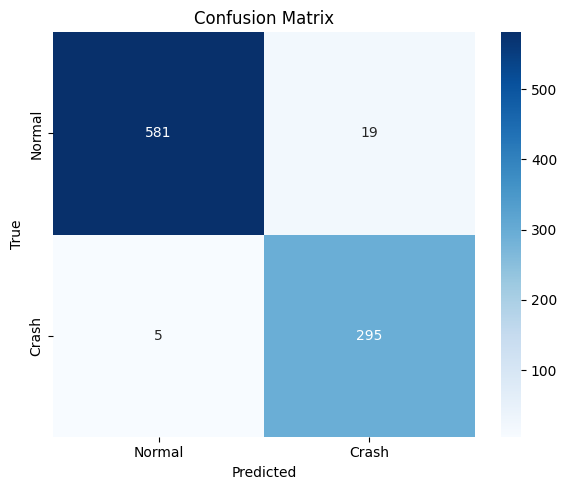

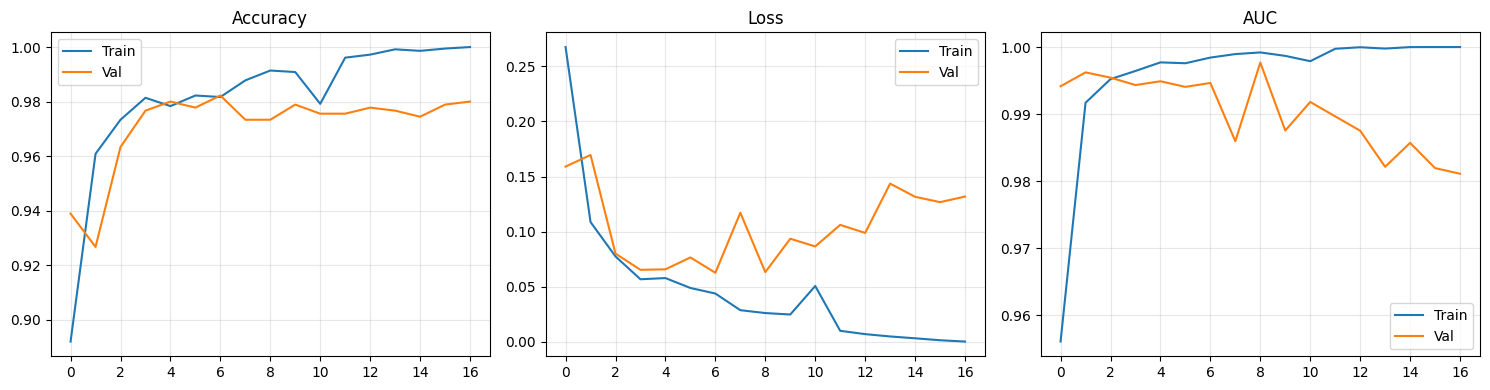

In [17]:
  # ============================================================
  # CELL 9: EVALUATE ON VALIDATION SET
  # ============================================================

  # Load best model
  best_model = keras.models.load_model(f'{MODELS_DIR}/best_crash_model.keras')

  # Full val set predictions
  all_preds, all_true = [], []
  for i in range(len(val_gen)):
      X_b, y_b = val_gen[i]
      preds = best_model.predict(X_b, verbose=0).flatten()
      all_preds.extend(preds)
      all_true.extend(y_b)

  all_preds = np.array(all_preds)
  all_true  = np.array(all_true)
  binary_preds = (all_preds >= 0.5).astype(int)

  print(classification_report(all_true, binary_preds, target_names=['Normal', 'Crash']))

  # Confusion matrix
  cm = confusion_matrix(all_true, binary_preds)
  plt.figure(figsize=(6, 5))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Normal','Crash'], yticklabels=['Normal','Crash'])
  plt.title('Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
  plt.tight_layout()
  plt.savefig(f'{RESULTS_DIR}/confusion_matrix.png', dpi=150)
  plt.show()

  # Training curves
  fig, axes = plt.subplots(1, 3, figsize=(15, 4))
  for ax, metric, label in zip(axes,
      ['accuracy', 'loss', 'auc'],
      ['Accuracy', 'Loss', 'AUC']):
      ax.plot(history.history[metric],     label='Train')
      ax.plot(history.history[f'val_{metric}'], label='Val')
      ax.set_title(label); ax.legend(); ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150)

In [18]:
  # ============================================================
  # CELL 10: SAVE FINAL MODEL + INFERENCE CODE
  # ============================================================

  # Save the feature extractor too — needed at inference time
  feature_extractor.save(f'{MODELS_DIR}/feature_extractor.keras')

  print("Saved:")
  print(f"  {MODELS_DIR}/best_crash_model.keras  — LSTM classifier")
  print(f"  {MODELS_DIR}/feature_extractor.keras — MobileNetV2 extractor")

  # ── Inference helper (paste into production crash_detection.py) ──
  INFERENCE_CODE = '''
  # ============================================================
  # INFERENCE — drop this into crash_detection.py
  # ============================================================
  import numpy as np, cv2
  import tensorflow as tf

  FRAME_SIZE    = 112
  FRAMES_SEQ    = 10
  CRASH_THRESH  = 0.55   # tune: higher = fewer false positives

  feature_extractor = tf.keras.models.load_model("models/feature_extractor.keras")
  crash_model       = tf.keras.models.load_model("models/best_crash_model.keras")
  preprocess        = tf.keras.applications.mobilenet_v2.preprocess_input

  frame_buffer = []   # rolling buffer

  def predict_crash(frame_bgr):
      """Call this on every frame. Returns (crash_prob, is_crash)."""
      global frame_buffer
      frame = cv2.resize(frame_bgr, (FRAME_SIZE, FRAME_SIZE))
      frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
      frame_buffer.append(frame)

      if len(frame_buffer) < FRAMES_SEQ:
          return 0.0, False
      if len(frame_buffer) > FRAMES_SEQ:
          frame_buffer.pop(0)

      batch   = preprocess(np.array(frame_buffer, dtype=np.float32))
      feats   = feature_extractor.predict(batch, verbose=0)   # (10, 1280)
      prob    = float(crash_model.predict(feats[np.newaxis], verbose=0)[0][0])
      return prob, prob >= CRASH_THRESH
  '''
  print(INFERENCE_CODE)


Saved:
  /content/drive/My Drive/CarCrashDetection/models/best_crash_model.keras  — LSTM classifier
  /content/drive/My Drive/CarCrashDetection/models/feature_extractor.keras — MobileNetV2 extractor

# ============================================================
# INFERENCE — drop this into crash_detection.py
# ============================================================
import numpy as np, cv2
import tensorflow as tf

FRAME_SIZE    = 112
FRAMES_SEQ    = 10
CRASH_THRESH  = 0.55   # tune: higher = fewer false positives

feature_extractor = tf.keras.models.load_model("models/feature_extractor.keras")
crash_model       = tf.keras.models.load_model("models/best_crash_model.keras")
preprocess        = tf.keras.applications.mobilenet_v2.preprocess_input

frame_buffer = []   # rolling buffer

def predict_crash(frame_bgr):
    """Call this on every frame. Returns (crash_prob, is_crash)."""
    global frame_buffer
    frame = cv2.resize(frame_bgr, (FRAME_SIZE, FRAME_SIZE))
    frame = cv2.cvtCo

In [19]:
  # ============================================================
  # FIX CELL: RE-SAVE WITH CPU-COMPATIBLE LSTM
  # ============================================================
  import os
  # Disable GPU so TF uses standard CPU LSTM ops (not CudNN)
  os.environ['CUDA_VISIBLE_DEVICES'] = ''
  import tensorflow as tf

  # Rebuild same architecture with CPU-safe LSTM
  from tensorflow import keras
  from tensorflow.keras import layers

  def build_model_cpu():
      inputs = keras.Input(shape=(10, 1280))
      x = layers.Dense(256, activation='relu')(inputs)
      x = layers.Dropout(0.3)(x)
      x = layers.LSTM(128, return_sequences=True)(x)
      x = layers.Dropout(0.3)(x)
      x = layers.LSTM(64, return_sequences=False)(x)
      x = layers.Dropout(0.3)(x)
      x = layers.Dense(64, activation='relu')(x)
      x = layers.Dropout(0.2)(x)
      output = layers.Dense(1, activation='sigmoid')(x)
      return keras.Model(inputs, output)

  # Load trained weights into CPU model
  trained = keras.models.load_model(f'{MODELS_DIR}/best_crash_model.keras')
  cpu_model = build_model_cpu()
  cpu_model.set_weights(trained.get_weights())

  # Export CPU-compatible SavedModel
  out = f'{MODELS_DIR}/crash_model_cpu'
  cpu_model.export(out)
  print(f"Done. Download folder: {out}")


Saved artifact at '/content/drive/My Drive/CarCrashDetection/models/crash_model_cpu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 1280), dtype=tf.float32, name='keras_tensor_377')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138723216801040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725559919504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725559925456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138723216799312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725559926032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725559926608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725559926224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725559926416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138725559924880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138722748072784: TensorSpec(shape=(

In [23]:
  # Save weights only (no ops baked in)
  trained = keras.models.load_model(f'{MODELS_DIR}/best_crash_model.keras')
  trained.save_weights(f'{MODELS_DIR}/crash_model_weights.weights.h5')
  print("Done — download crash_model_weights.weights.h5")

Done — download crash_model_weights.weights.h5
